# 📊 Análise de Despesas Pessoais

Projeto desenvolvido para praticar **Python** e **Pandas**, como complemento aos estudos do curso **IBM Data Science**.

O objetivo é analisar um conjunto de despesas pessoais fictícias (6 meses, 5 categorias) para responder a perguntas como:
- Qual foi o total gasto no período?
- Qual categoria consome mais do orçamento?
- Como os gastos variam mês a mês?

**Ferramentas utilizadas:** Python, Pandas, Matplotlib

## 1. Carregando os dados

Os dados estão num ficheiro CSV com três colunas: `data`, `categoria` e `valor`.

In [3]:
import pandas as pd
df = pd.read_csv('despesas.csv')
df

,data,categoria,valor
0,2026-01-05,Alimentação,45.5
1,2026-01-07,Transporte,20.0
2,2026-01-10,Lazer,60.0
3,2026-01-12,Alimentação,32.1
4,2026-01-15,Contas,150.0
5,2026-01-20,Saúde,35.0
6,2026-01-25,Alimentação,28.9
7,2026-02-03,Transporte,22.0
8,2026-02-06,Lazer,45.0
9,2026-02-10,Alimentação,50.2


## 2. Explorando a estrutura dos dados

Antes de analisar, é importante verificar os tipos de dados de cada coluna.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   data       42 non-null     object 
 1   categoria  42 non-null     object 
 2   valor      42 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.1+ KB


## 3. Total de gastos no período

In [5]:
total_gastos = df['valor'].sum()
total_gastos

np.float64(2483.3)

## 4. Gastos por categoria

Agrupando os valores por categoria, é possível identificar onde o dinheiro está sendo mais consumido.

In [6]:
gastos_por_categoria = df.groupby('categoria')['valor'].sum()
gastos_por_categoria

categoria
Alimentação     551.3
Contas         1073.0
Lazer           452.0
Saúde           237.0
Transporte      170.0
Name: valor, dtype: float64

In [7]:
categoria_maior_gasto = gastos_por_categoria.idxmax()
categoria_maior_gasto

'Contas'

In [9]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Visualização: gastos por categoria

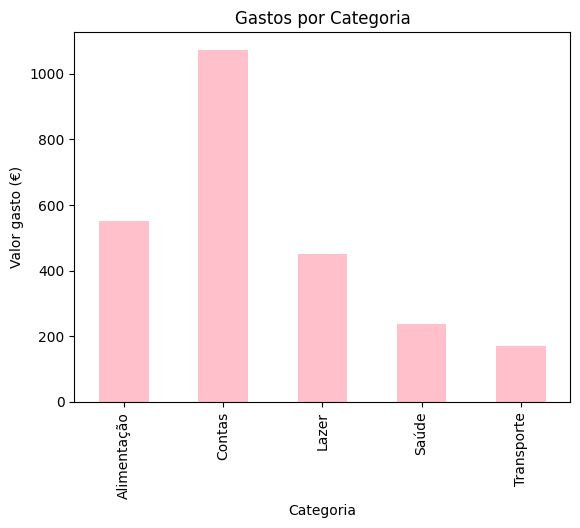

In [13]:
import matplotlib.pyplot as plt

gastos_por_categoria.plot(kind='bar', title='Gastos por Categoria', color='pink')
plt.xlabel('Categoria')
plt.ylabel('Valor gasto (€)')
plt.show()

## 5. Evolução dos gastos ao longo dos meses

Para analisar por mês, é necessário converter a coluna `data` para o formato de data e extrair o mês de cada registro.

In [15]:
df['data'] = pd.to_datetime(df['data'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data       42 non-null     datetime64[ns]
 1   categoria  42 non-null     object        
 2   valor      42 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.1+ KB


In [17]:
df['mes'] = df['data'].dt.month
df.head()

,data,categoria,valor,mes
0,2026-01-05,Alimentação,45.5,1
1,2026-01-07,Transporte,20.0,1
2,2026-01-10,Lazer,60.0,1
3,2026-01-12,Alimentação,32.1,1
4,2026-01-15,Contas,150.0,1


In [18]:
gastos_por_mes = df.groupby('mes')['valor'].sum()
gastos_por_mes

mes
1    371.5
2    363.8
3    441.3
4    367.8
5    540.5
6    398.4
Name: valor, dtype: float64

### Visualização: evolução mensal dos gastos

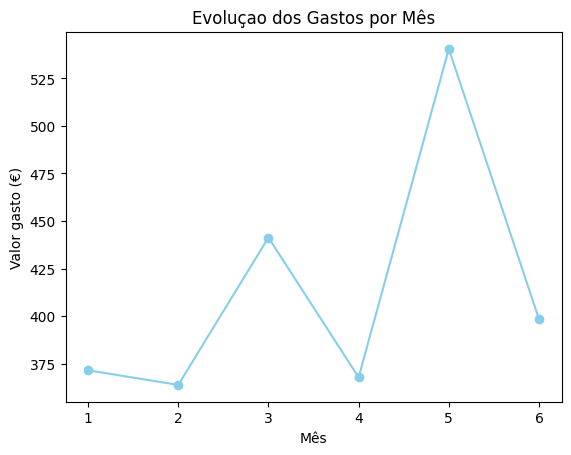

In [19]:
gastos_por_mes.plot(kind='line', title='Evoluçao dos Gastos por Mês', color='skyblue', marker='o')
plt.xlabel('Mês')
plt.ylabel('Valor gasto (€)')
plt.show()

## Conclusões

- O total gasto no período analisado foi de **2.483,30€**.
- A categoria com maior peso no orçamento foi **Contas**, seguida de **Alimentação**.
- O mês com maior gasto foi **maio**, com **540,50€** — bem acima da média dos outros meses.

Este projeto demonstrou o uso de **Pandas** para leitura, agregação (`groupby`) e manipulação de datas, além de visualização de dados com **Matplotlib**.